# Optuna Hyperparameter Tuning: BiGRU + Attention + Metadata

This notebook tunes hyperparameters for the BiGRU+Attention model with metadata features.

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler

import optuna
from optuna.trial import TrialState

import fasttext
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

# Fixed config
RANDOM_SEED = 42
MAX_LENGTH = 256
N_TRIALS = 40
N_FOLDS = 3

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


Device: cuda


In [2]:
# Load data
DATA_DIR = Path('/kaggle/input/steam-review')
MODEL_DIR = Path('/kaggle/input/fasttext-steam-200/other/default/1')

train_df = pd.read_csv(DATA_DIR / 'train.csv')
X_train = train_df['processed_text'].fillna('').values
y_train = train_df['voted_up'].astype(int).values
stratify_key = train_df['voted_up'].astype(str) + '_' + train_df['primary_genre'].astype(str)

# Encode metadata
genre_encoder = LabelEncoder()
playtime_tier_encoder = LabelEncoder()
length_tier_encoder = LabelEncoder()

genre_encoder.fit(train_df['primary_genre'])
playtime_tier_encoder.fit(train_df['playtime_tier'])
length_tier_encoder.fit(train_df['length_tier'])

train_df['genre_id'] = genre_encoder.transform(train_df['primary_genre'])
train_df['playtime_tier_id'] = playtime_tier_encoder.transform(train_df['playtime_tier'])
train_df['length_tier_id'] = length_tier_encoder.transform(train_df['length_tier'])

genre_ids_train = train_df['genre_id'].values
playtime_tier_ids_train = train_df['playtime_tier_id'].values
length_tier_ids_train = train_df['length_tier_id'].values

NUM_GENRES = len(genre_encoder.classes_)
NUM_PLAYTIME_TIERS = len(playtime_tier_encoder.classes_)
NUM_LENGTH_TIERS = len(length_tier_encoder.classes_)

# Load FastText
ft_model = fasttext.load_model(str(MODEL_DIR / 'steam_fasttext.bin'))
EMBEDDING_DIM = ft_model.get_dimension()
print(f"Loaded: {len(train_df)} samples, {EMBEDDING_DIM}-dim embeddings")
print(f"Metadata: {NUM_GENRES} genres, {NUM_PLAYTIME_TIERS} playtime tiers, {NUM_LENGTH_TIERS} length tiers")

Loaded: 34481 samples, 200-dim embeddings
Metadata: 12 genres, 4 playtime tiers, 3 length tiers


In [3]:
class SteamReviewDatasetWithMetadata(Dataset):
    def __init__(self, texts, labels, genre_ids, playtime_tier_ids, length_tier_ids,
                 ft_model, max_length=256):
        self.texts = texts
        self.labels = labels
        self.genre_ids = genre_ids
        self.playtime_tier_ids = playtime_tier_ids
        self.length_tier_ids = length_tier_ids
        self.ft_model = ft_model
        self.max_length = max_length
        self.embedding_dim = ft_model.get_dimension()
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        text = self.texts[idx]
        tokens = text.split()[:self.max_length]
        embeddings = np.zeros((self.max_length, self.embedding_dim), dtype=np.float32)
        for i, token in enumerate(tokens):
            embeddings[i] = self.ft_model.get_word_vector(token)
        mask = np.zeros(self.max_length, dtype=np.float32)
        mask[:len(tokens)] = 1.0
        return {
            'embeddings': torch.tensor(embeddings, dtype=torch.float32),
            'mask': torch.tensor(mask, dtype=torch.float32),
            'label': torch.tensor(self.labels[idx], dtype=torch.float32),
            'genre_id': torch.tensor(self.genre_ids[idx], dtype=torch.long),
            'playtime_tier_id': torch.tensor(self.playtime_tier_ids[idx], dtype=torch.long),
            'length_tier_id': torch.tensor(self.length_tier_ids[idx], dtype=torch.long)
        }


class Attention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1, bias=False)
        )
    
    def forward(self, gru_output, mask):
        scores = self.attention(gru_output).squeeze(-1)
        scores = scores.masked_fill(mask == 0, -1e4)
        attention_weights = torch.softmax(scores, dim=1)
        context = torch.bmm(attention_weights.unsqueeze(1), gru_output).squeeze(1)
        return context


class BiGRUAttentionWithMetadata(nn.Module):
    def __init__(self, embedding_dim, hidden_dim, num_layers, dropout,
                 num_genres, num_playtime_tiers, num_length_tiers, metadata_embed_dim):
        super().__init__()
        
        self.gru = nn.GRU(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.attention = Attention(hidden_dim * 2)
        
        # Metadata embeddings
        self.genre_embed = nn.Embedding(num_genres, metadata_embed_dim)
        self.playtime_tier_embed = nn.Embedding(num_playtime_tiers, metadata_embed_dim)
        self.length_tier_embed = nn.Embedding(num_length_tiers, metadata_embed_dim)
        
        combined_dim = hidden_dim * 2 + metadata_embed_dim * 3
        
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    def forward(self, embeddings, mask, genre_ids, playtime_tier_ids, length_tier_ids):
        self.gru.flatten_parameters()
        gru_output, _ = self.gru(embeddings)
        context = self.attention(gru_output, mask)
        
        genre_emb = self.genre_embed(genre_ids)
        playtime_emb = self.playtime_tier_embed(playtime_tier_ids)
        length_emb = self.length_tier_embed(length_tier_ids)
        
        combined = torch.cat([context, genre_emb, playtime_emb, length_emb], dim=-1)
        return self.classifier(combined)

In [4]:
def train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, scaler, device, n_epochs=10):
    """Train model and return best validation F1."""
    best_f1 = 0
    patience, patience_counter = 3, 0
    
    for epoch in range(n_epochs):
        # Train
        model.train()
        for batch in train_loader:
            embeddings = batch['embeddings'].to(device)
            mask = batch['mask'].to(device)
            labels = batch['label'].to(device)
            genre_ids = batch['genre_id'].to(device)
            playtime_tier_ids = batch['playtime_tier_id'].to(device)
            length_tier_ids = batch['length_tier_id'].to(device)
            
            optimizer.zero_grad()
            with autocast(device_type=device.type):
                logits = model(embeddings, mask, genre_ids, playtime_tier_ids, length_tier_ids).squeeze(-1)
                loss = criterion(logits, labels)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
        
        # Validate
        model.eval()
        all_preds, all_labels = [], []
        with torch.no_grad():
            for batch in val_loader:
                embeddings = batch['embeddings'].to(device)
                mask = batch['mask'].to(device)
                labels = batch['label'].to(device)
                genre_ids = batch['genre_id'].to(device)
                playtime_tier_ids = batch['playtime_tier_id'].to(device)
                length_tier_ids = batch['length_tier_id'].to(device)
                with autocast(device_type=device.type):
                    logits = model(embeddings, mask, genre_ids, playtime_tier_ids, length_tier_ids).squeeze(-1)
                preds = (torch.sigmoid(logits) > 0.5).float()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(labels.cpu().numpy())
        
        val_f1 = f1_score(all_labels, all_preds)
        
        if val_f1 > best_f1:
            best_f1 = val_f1
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break
    
    return best_f1

In [5]:
def objective(trial):
    """Optuna objective function."""
    
    # Hyperparameters to tune
    hidden_dim = trial.suggest_categorical('hidden_dim', [64, 128, 256])
    num_layers = trial.suggest_int('num_layers', 1, 3)
    dropout = trial.suggest_float('dropout', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64])
    metadata_embed_dim = trial.suggest_categorical('metadata_embed_dim', [8, 16, 32])
    
    # Cross-validation
    skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    fold_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(skf.split(X_train, stratify_key)):
        X_fold_train, X_fold_val = X_train[train_idx], X_train[val_idx]
        y_fold_train, y_fold_val = y_train[train_idx], y_train[val_idx]
        genre_fold_train, genre_fold_val = genre_ids_train[train_idx], genre_ids_train[val_idx]
        playtime_fold_train, playtime_fold_val = playtime_tier_ids_train[train_idx], playtime_tier_ids_train[val_idx]
        length_fold_train, length_fold_val = length_tier_ids_train[train_idx], length_tier_ids_train[val_idx]
        
        train_dataset = SteamReviewDatasetWithMetadata(
            X_fold_train, y_fold_train, genre_fold_train, playtime_fold_train, length_fold_train,
            ft_model, MAX_LENGTH
        )
        val_dataset = SteamReviewDatasetWithMetadata(
            X_fold_val, y_fold_val, genre_fold_val, playtime_fold_val, length_fold_val,
            ft_model, MAX_LENGTH
        )
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
        
        model = BiGRUAttentionWithMetadata(
            EMBEDDING_DIM, hidden_dim, num_layers, dropout,
            NUM_GENRES, NUM_PLAYTIME_TIERS, NUM_LENGTH_TIERS, metadata_embed_dim
        ).to(device)
        
        optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        criterion = nn.BCEWithLogitsLoss()
        scaler = GradScaler()
        
        fold_f1 = train_and_evaluate(model, train_loader, val_loader, optimizer, criterion, scaler, device)
        fold_scores.append(fold_f1)
        
        # Pruning
        trial.report(np.mean(fold_scores), fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    
    return np.mean(fold_scores)

In [6]:
# Create and run study
study = optuna.create_study(direction='maximize', pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\nBEST HYPERPARAMETERS - BiGRU+Attention+Metadata")
print(f"Best F1 Score: {study.best_value:.4f}")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2025-12-27 20:15:26,900] A new study created in memory with name: no-name-a2ab486d-282a-405e-a1c5-eb9f6223238a


  0%|          | 0/40 [00:00<?, ?it/s]

[I 2025-12-27 20:28:00,938] Trial 0 finished with value: 0.8842882704830903 and parameters: {'hidden_dim': 64, 'num_layers': 3, 'dropout': 0.4013832408619605, 'learning_rate': 0.0003864433186723703, 'weight_decay': 1.3998922969110201e-05, 'batch_size': 32, 'metadata_embed_dim': 32}. Best is trial 0 with value: 0.8842882704830903.
[I 2025-12-27 20:40:02,376] Trial 1 finished with value: 0.8864236343706781 and parameters: {'hidden_dim': 64, 'num_layers': 2, 'dropout': 0.283080450193401, 'learning_rate': 0.0007460820272022428, 'weight_decay': 0.01642987726833057, 'batch_size': 64, 'metadata_embed_dim': 16}. Best is trial 1 with value: 0.8864236343706781.
[I 2025-12-27 20:50:34,001] Trial 2 finished with value: 0.8743126849822606 and parameters: {'hidden_dim': 256, 'num_layers': 1, 'dropout': 0.41638521892037006, 'learning_rate': 0.003604528186930437, 'weight_decay': 2.0829514769166624e-05, 'batch_size': 32, 'metadata_embed_dim': 32}. Best is trial 1 with value: 0.8864236343706781.
[I 2025

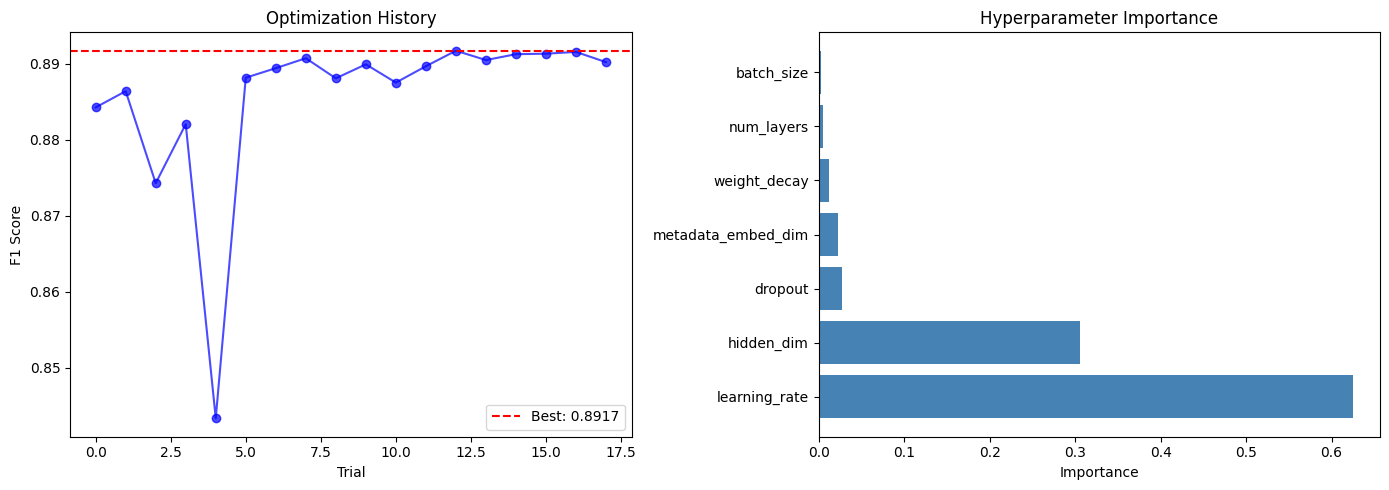

In [7]:
# Visualize optimization
import matplotlib.pyplot as plt
from optuna.importance import MeanDecreaseImpurityImportanceEvaluator

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Optimization history
trials = [t for t in study.trials if t.state == TrialState.COMPLETE]
values = [t.value for t in trials]
axes[0].plot(values, 'bo-', alpha=0.7)
axes[0].axhline(y=study.best_value, color='r', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial')
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Optimization History')
axes[0].legend()

# Hyperparameter importance (using MDI evaluator to avoid fANOVA issues)
try:
    importance = optuna.importance.get_param_importances(
        study, 
        evaluator=MeanDecreaseImpurityImportanceEvaluator()
    )
    params = list(importance.keys())
    importances = list(importance.values())
    axes[1].barh(params, importances, color='steelblue')
    axes[1].set_xlabel('Importance')
    axes[1].set_title('Hyperparameter Importance')
except Exception as e:
    print(f'Could not compute param importances: {e}')
    axes[1].text(0.5, 0.5, 'Importance unavailable', ha='center', va='center')
    axes[1].set_title('Hyperparameter Importance (Error)')

plt.tight_layout()
plt.show()

In [8]:
# Save best params
import json

best_config = {
    'model': 'BiGRU+Attention+Metadata',
    'best_f1': study.best_value,
    'best_params': study.best_params
}

print(json.dumps(best_config, indent=2))

{
  "model": "BiGRU+Attention+Metadata",
  "best_f1": 0.8917469349711076,
  "best_params": {
    "hidden_dim": 64,
    "num_layers": 3,
    "dropout": 0.20068592388224113,
    "learning_rate": 0.0016732285791048196,
    "weight_decay": 0.00013399625935258818,
    "batch_size": 32,
    "metadata_embed_dim": 32
  }
}
